# Week 7

Finally made the classes done :))

## Phi vals initial fit

In [13]:
from src.api.v4 import HMM, GaussEmission, StaticTransition, AutoregressiveGaussEmission
from src.api.v4 import LBFGSSolver, GradientSolver, Minimizer
import jax.numpy as jnp 
from src.api.v4.utils import phi_to_phi_tilde 
from src.api.v4.utils import load_y_data
import matplotlib.pyplot as plt
from src.api.v4 import ForwardAlgorithm
from src.api.v4 import StaticTransitionHigherOrder


mean = jnp.array([400, 536, 890, 1307]) 
sd = jnp.array([22, 77, 111, 197])  
u0 = jnp.array([0.19, 0.35, 0.15, 0.32])
Gamma = jnp.array([
            [8.5e-01, 1.5e-01, 0.0028, 9.7e-09],
            [8.3e-02, 8.5e-01, 0.0679, 6.8e-09],
            [4.3e-04, 1.6e-01, 0.6842, 1.5e-01],
            [2.6e-08, 6.1e-09, 0.0723, 9.3e-01],]
            )

gauss_emission = GaussEmission.from_params(mu=mean, sigma=sd)
arr_emission = AutoregressiveGaussEmission.from_params(mu=mean, sigma=sd, phi=jnp.array([0.2, 0.4, 0.8, 0.5]))
transition = StaticTransition.from_params(Gamma)
ar_hmm = HMM(transition=transition, emission=arr_emission, inital_distribution=u0) 



ys = load_y_data() 
ar_hmm.fit(ys=ys, solver=LBFGSSolver(), frozen={"mu0": False})

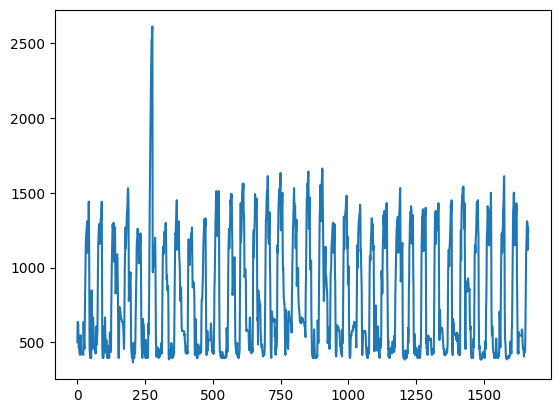

In [14]:

plt.plot(ys)

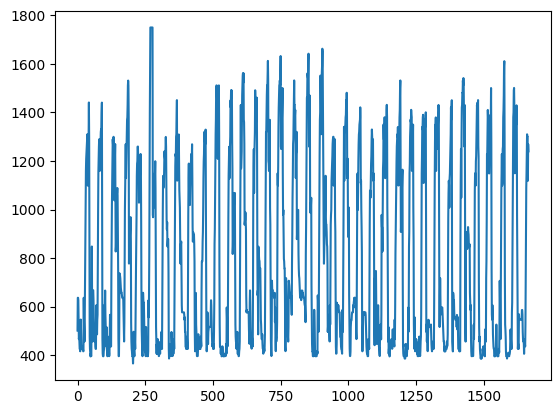

In [15]:
ys_clipped = jnp.clip(ys, a_min=0, a_max=1750)  # Ensure no negative values
plt.plot(ys_clipped)

### We now do it for a higher order markov chain 

Transition matrix for order 2 HMM:
[[1.3705824e-01 8.6294168e-01 0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 0.0000000e+00 2.3277673e-01 7.6722330e-01]
 [0.0000000e+00 0.0000000e+00 4.6730204e-03 9.9532700e-01]
 [2.8026328e-08 1.0000000e+00 0.0000000e+00 0.0000000e+00]]
[[-5.9604645e-08  4.4765374e-01  1.0469258e-01  4.4765368e-01]]


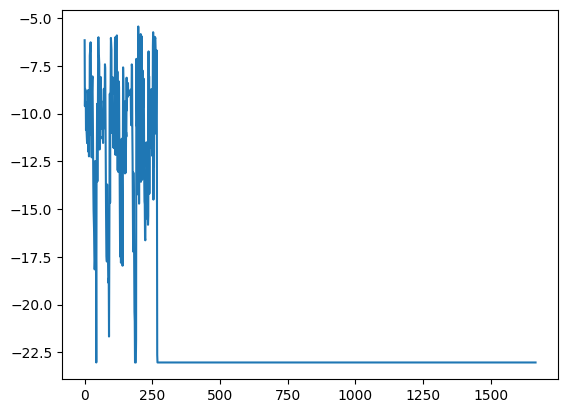

In [16]:

logits = ar_hmm.transition.transition_logits[:, 0]

transition_matrix = StaticTransitionHigherOrder(transition_logits=logits, order = 2, num_states=2) 
gauss_emission = GaussEmission.from_params(mu=mean, sigma=sd)
hmm_order_2 = HMM(transition=transition_matrix, emission=gauss_emission) 


params = hmm_order_2.params 
alg = ForwardAlgorithm() 
u0 = hmm_order_2._compute_stationary_distribution() 

output = alg.run(params, u0, ys)

nan_ids = jnp.where(jnp.isnan(output.ft))[0]


plt.plot(jnp.log(output.ft))


print("Transition matrix for order 2 HMM:")
print(hmm_order_2.transition.transition_matrix())
print(hmm_order_2._compute_stationary_distribution())

Transition matrix for order 2 HMM after fitting:
[[0.96000004 0.04       0.         0.        ]
 [0.         0.         0.027      0.97300005]
 [0.         0.         0.004      0.99600005]
 [0.096      0.90400004 0.         0.        ]]
Parameter: transition
  transition_logits: [ 3.1702607 -3.5996778 -5.4224    -2.2421517]
  order: 2
Parameter: emission
  log_mu_diff: [ 6.7677884 -2.794669  -0.2743354]
  mu0: 400.0
  log_sigma: [ 4.9002023  5.6137376 -1.0982157  5.630269 ]
Transition matrix for order 2 HMM:
[[0.9596997  0.04030034 0.         0.        ]
 [0.         0.         0.02660534 0.97339463]
 [0.         0.         0.00439711 0.99560285]
 [0.0960286  0.90397143 0.         0.        ]]
[[0.54037833 0.22678053 0.00606027 0.22678101]]


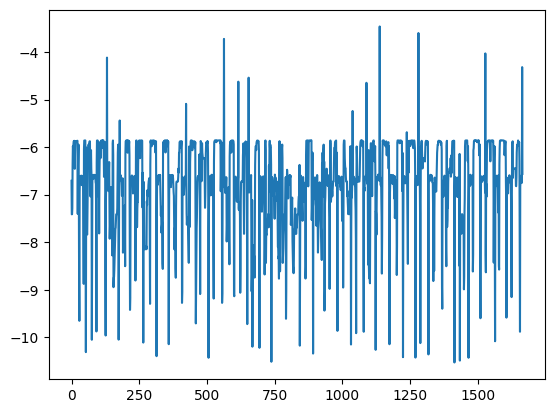

In [17]:
hmm_order_2.fit(ys=ys, solver=LBFGSSolver(), frozen={"mu0": False}) 

print("Transition matrix for order 2 HMM after fitting:")

#Format it to be more readable
print(jnp.round(hmm_order_2.transition.transition_matrix(), 3))

for p, v in hmm_order_2.params: 
    print(f"Parameter: {p}")
    for param, value in v:
        print(f"  {param}: {value}")



params = hmm_order_2.params 
alg = ForwardAlgorithm() 
u0 = hmm_order_2._compute_stationary_distribution() 

output = alg.run(params, u0, ys_clipped)

nan_ids = jnp.where(jnp.isnan(output.ft))[0]


plt.plot(jnp.log(output.ft))


print("Transition matrix for order 2 HMM:")
print(hmm_order_2.transition.transition_matrix())
print(hmm_order_2._compute_stationary_distribution())


Using the clipped ys data

Transition matrix for order 2 HMM:
[[1.3705824e-01 8.6294168e-01 0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 0.0000000e+00 2.3277673e-01 7.6722330e-01]
 [0.0000000e+00 0.0000000e+00 4.6730204e-03 9.9532700e-01]
 [2.8026328e-08 1.0000000e+00 0.0000000e+00 0.0000000e+00]]
[[-5.9604645e-08  4.4765374e-01  1.0469258e-01  4.4765368e-01]]


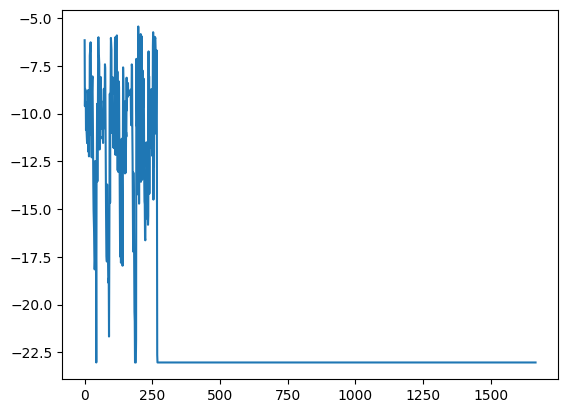

In [18]:
logits = ar_hmm.transition.transition_logits[:, 0]

transition_matrix = StaticTransitionHigherOrder(transition_logits=logits, order = 2, num_states=2) 
gauss_emission = GaussEmission.from_params(mu=mean, sigma=sd)
hmm_order_2 = HMM(transition=transition_matrix, emission=gauss_emission) 


params = hmm_order_2.params 
alg = ForwardAlgorithm() 
u0 = hmm_order_2._compute_stationary_distribution() 

output = alg.run(params, u0, ys_clipped)

nan_ids = jnp.where(jnp.isnan(output.ft))[0]


plt.plot(jnp.log(output.ft))


print("Transition matrix for order 2 HMM:")
print(hmm_order_2.transition.transition_matrix())
print(hmm_order_2._compute_stationary_distribution())

We fit the ys on the higher order markov chain, 

In [19]:
for _ in range(3):
    hmm_order_2.fit(ys=ys, solver=LBFGSSolver(), frozen={"mu0": False}) 

print("Transition matrix for order 2 HMM after fitting:")

#Format it to be more readable
print(jnp.round(hmm_order_2.transition.transition_matrix(), 3))

for p, v in hmm_order_2.params: 
    print(f"Parameter: {p}")
    for param, value in v:
        print(f"  {param}: {value}")

Transition matrix for order 2 HMM after fitting:
[[0.95800006 0.042      0.         0.        ]
 [0.         0.         0.009      0.99100006]
 [0.         0.         0.004      0.99600005]
 [0.09900001 0.901      0.         0.        ]]
Parameter: transition
  transition_logits: [ 3.1188993 -4.671385  -5.473085  -2.2083838]
  order: 2
Parameter: emission
  log_mu_diff: [ 6.644719   -2.7946432  -0.28281847]
  mu0: 400.0
  log_sigma: [ 4.859899   5.577763  -3.099764   5.5963016]


In [20]:
hmm_order_2.emission.mu(0, ys=ys)

Array([ 400.    , 1168.7141, 1168.7753, 1169.5289], dtype=float32)

Transition matrix for order 2 HMM:
[[0.9576656  0.04233437 0.         0.        ]
 [0.         0.         0.00927252 0.9907274 ]
 [0.         0.         0.00418071 0.9958192 ]
 [0.09900015 0.9009999  0.         0.        ]]
[[0.5378597  0.22999907 0.00214161 0.22999918]]


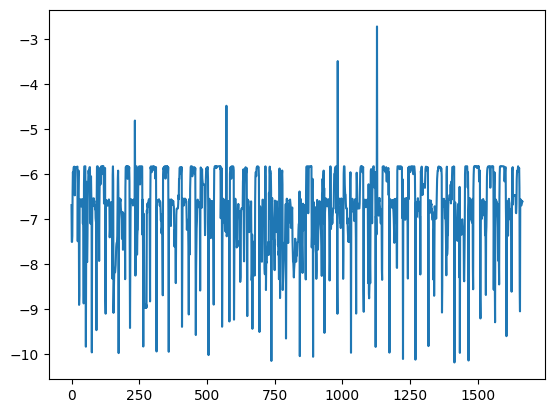

In [21]:
params = hmm_order_2.params 
alg = ForwardAlgorithm() 
u0 = hmm_order_2._compute_stationary_distribution() 

output = alg.run(params, u0, ys_clipped)

nan_ids = jnp.where(jnp.isnan(output.ft))[0]


plt.plot(jnp.log(output.ft))


print("Transition matrix for order 2 HMM:")
print(hmm_order_2.transition.transition_matrix())
print(hmm_order_2._compute_stationary_distribution())

### Pseudo residuals

In [10]:
import matplotlib.pyplot as plt 

z_arr = ar_hmm.pseudo_residuals(ys=ys)
z_order2 = hmm_order_2.pseudo_residuals(ys=ys) 
z_finite_2 = z_order2[jnp.isfinite(z_order2)] 


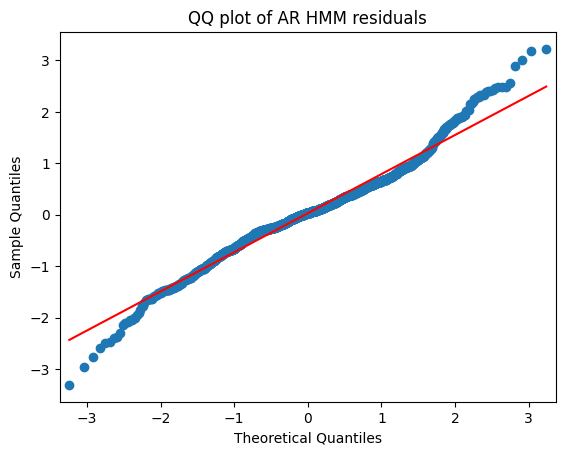

In [11]:
import statsmodels.api as sm

sm.qqplot(z_arr, line='s')
plt.title("QQ plot of AR HMM residuals")
plt.show()

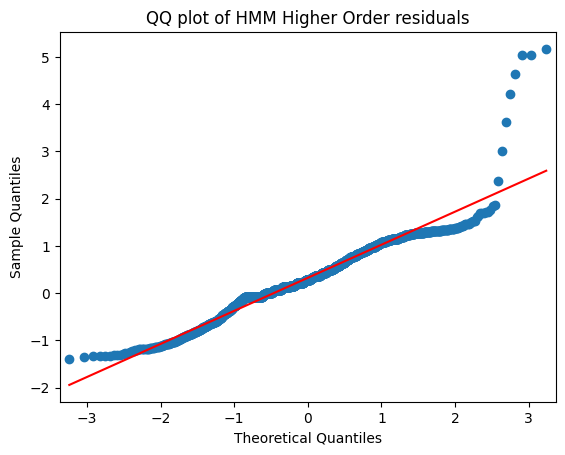

In [12]:
sm.qqplot(z_finite_2, line='s')
plt.title("QQ plot of HMM Higher Order residuals")
plt.show()